In [1]:
#https://drive.google.com/file/d/1CppeqGbiBzX61jx56gcXyGGDNEeLlJ-W/view?usp=share_link
!gdown 1CppeqGbiBzX61jx56gcXyGGDNEeLlJ-W

Downloading...
From: https://drive.google.com/uc?id=1CppeqGbiBzX61jx56gcXyGGDNEeLlJ-W
To: /content/train_loan_imbalanced.csv
100% 38.0k/38.0k [00:00<00:00, 38.4MB/s]


In [2]:
import pandas as pd
df = pd.read_csv('/content/train_loan_imbalanced.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import SMOTENC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import  MinMaxScaler
seed = 42

In [4]:
df.drop('Loan_ID', axis=1, inplace=True)
df.shape

(614, 12)

In [5]:
df.isna().sum()

,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14
Credit_History,50


In [6]:
df.dropna(inplace=True, axis=0)
print(df.shape)

(480, 12)


In [7]:
# Convert 'Dependents' to numeric by replacing '3+' with 3 and then casting to int
df['Dependents'] = df['Dependents'].replace('3+', 3).astype(int)

# Convert 'Loan_Status' to numeric (0 for 'N', 1 for 'Y')
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

# Identify remaining object columns for one-hot encoding
object_cols = df.select_dtypes(include=['object']).columns

# Apply one-hot encoding to the remaining categorical columns
df = pd.get_dummies(df, columns=object_cols, drop_first=True)

print("DataFrame after converting all values to numeric:")
print(df.head())
print("\nDataFrame Info:")
df.info()

DataFrame after converting all values to numeric:
   Dependents  ApplicantIncome  CoapplicantIncome  LoanAmount  \
1           1             4583             1508.0       128.0   
2           0             3000                0.0        66.0   
3           0             2583             2358.0       120.0   
4           0             6000                0.0       141.0   
5           2             5417             4196.0       267.0   

   Loan_Amount_Term  Credit_History  Loan_Status  Gender_Male  Married_Yes  \
1             360.0             1.0            0         True         True   
2             360.0             1.0            1         True         True   
3             360.0             1.0            1         True         True   
4             360.0             1.0            1         True        False   
5             360.0             1.0            1         True         True   

   Education_Not Graduate  Self_Employed_Yes  Property_Area_Semiurban  \
1                

In [8]:
y = df['Loan_Status']
X = df.drop('Loan_Status', axis=1)
print(X.shape, y.shape)

(480, 12) (480,)


In [9]:
X['Dependents'].value_counts()

,count
Dependents,
0,274
2,85
1,80
3,41


In [10]:
tmp = X.select_dtypes(include=["object_"])
cols = tmp.columns
catList = [df.columns.get_loc(c) for c in cols if c in df]
catList

[]

In [11]:
# Perform train-test split using the already preprocessed X and y
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.20, random_state=seed)
X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(Y_train)
y_test = np.array(Y_test)

# Define the categorical features for SMOTENC based on the current X_train columns:
# 0: Dependents (int, categorical)
# 5: Credit_History (float, categorical 0.0/1.0)
# 6: Gender_Male (bool, categorical)
# 7: Married_Yes (bool, categorical)
# 8: Education_Not Graduate (bool, categorical)
# 9: Self_Employed_Yes (bool, categorical)
# 10: Property_Area_Semiurban (bool, categorical)
# 11: Property_Area_Urban (bool, categorical)
categorical_features_indices = [0, 5, 6, 7, 8, 9, 10, 11]

#sm = SMOTENC(categorical_features=categorical_features_indices, random_state=seed)
#X_res, y_res = sm.fit_resample(X_train, Y_train)

sm = SMOTENC(categorical_features = categorical_features_indices, random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

X_res = np.array(X_res)
y_res = np.array(y_res)

scaler = MinMaxScaler()
X_res = scaler.fit_transform(X_res)
X_test = scaler.transform(X_test)

print("Shape after SMOTENC:", X_res.shape, y_res.shape)
print("Class distribution after SMOTENC:\n", pd.Series(y_res).value_counts())

model = LogisticRegression()
model.fit(X_res, y_res)

train_preds_lr = model.predict(X_res)
test_preds_lr = model.predict(X_test)
print("Predictions generated successfully.")

Shape after SMOTENC: (528, 12) (528,)
Class distribution after SMOTENC:
 0    264
1    264
Name: count, dtype: int64
Predictions generated successfully.


In [12]:
!pip install pulp # for partial dependence plots!
!pip install pycebox
from pycebox.ice import ice, ice_plot

In [13]:
from sklearn.inspection import permutation_importance

/tmp/ipykernel_15264/166718805.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(result.importances[perm_sorted_idx].T, vert=False,


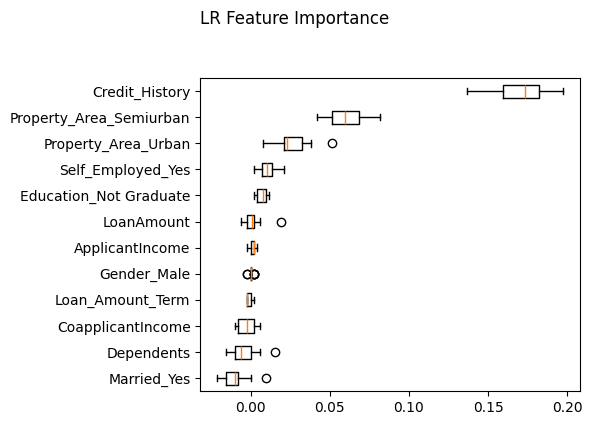

In [14]:
clf = model

result = permutation_importance(clf, X_res, y_res, n_repeats=20,
                                random_state=42)
perm_sorted_idx = result.importances_mean.argsort()

fig, ax1 = plt.subplots(1, 1, figsize=(6, 4))
ax1.boxplot(result.importances[perm_sorted_idx].T, vert=False,
            labels=X.columns[perm_sorted_idx])
fig.suptitle('LR Feature Importance', y=1.05) # don't forget to update title!
fig.tight_layout()
plt.show()

In [15]:
top5_features = perm_sorted_idx[7:]
top5_features = X.columns[top5_features]
print(top5_features)

Index(['Education_Not Graduate', 'Self_Employed_Yes', 'Property_Area_Urban',
       'Property_Area_Semiurban', 'Credit_History'],
      dtype='object')


In [16]:
train_X_df = pd.DataFrame(X_res, columns=X.columns)
train_X_df.head()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,1.000000,0.041707,0.000000,0.121827,0.324324,1.0,1.0,1.0,1.0,0.0,0.0,0.0
1,0.000000,0.049153,0.000000,0.179357,0.729730,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.666667,0.047458,0.041700,0.250423,0.729730,1.0,1.0,1.0,1.0,0.0,0.0,0.0
3,0.666667,0.031639,0.034489,0.148900,0.729730,1.0,1.0,1.0,0.0,0.0,1.0,0.0
4,1.000000,0.093878,0.000000,0.201354,0.324324,1.0,1.0,1.0,0.0,0.0,0.0,1.0


(2, 527)


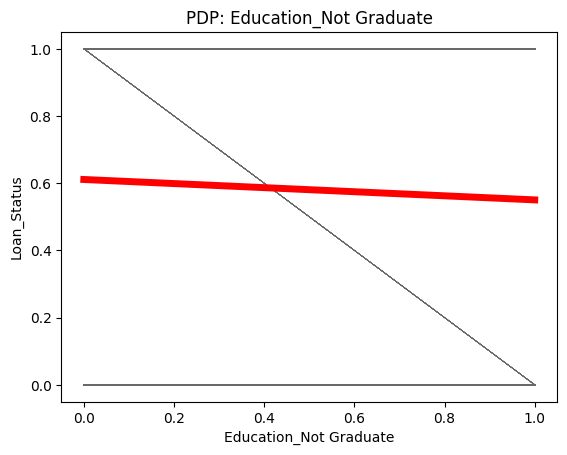

(2, 527)


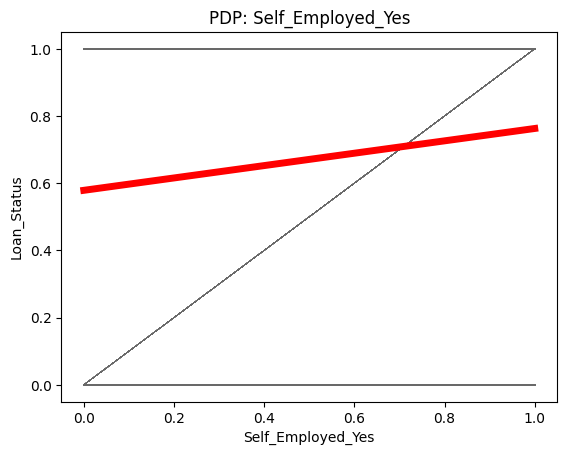

(2, 527)


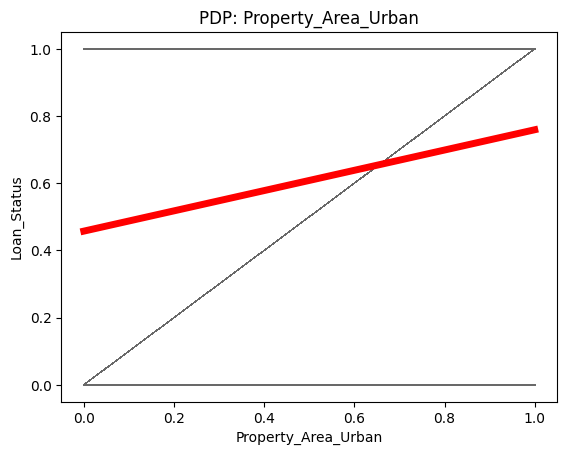

(2, 527)


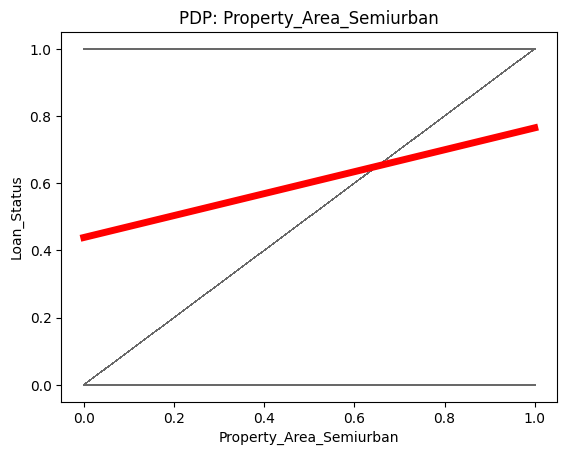

(2, 527)


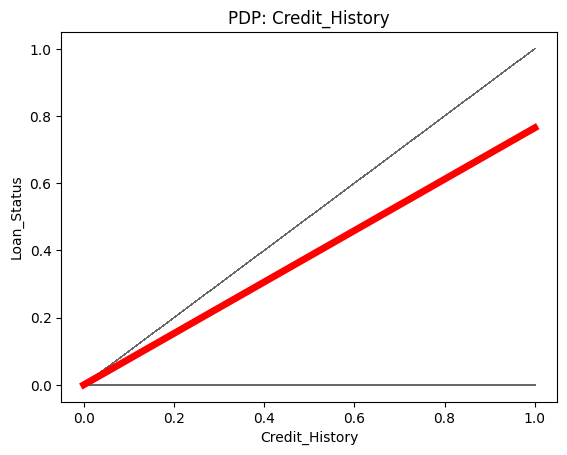

In [17]:
for col in top5_features:
  tmpdf = ice(data=train_X_df, # ice needs a dataframe
            column=col, # the column name
                   predict=model.predict) # the predict statement from the
                                          # model
  print(np.shape(tmpdf))
  ice_plot(tmpdf, c='dimgray', linewidth=0.3,
                  plot_pdp=True,
         pdp_kwargs={'linewidth': 5, 'color':'red'})
  plt.title(f'PDP: {col}')
  plt.ylabel('Loan_Status')
  plt.xlabel(col);
  plt.show()

/tmp/ipykernel_15264/1118368936.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(resultDTC.importances[perm_sorted_idxDTC].T, vert=False, labels=X.columns[perm_sorted_idxDTC])


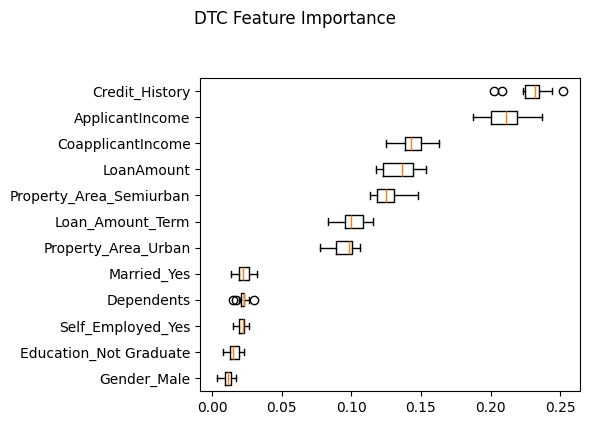

Index(['Property_Area_Semiurban', 'LoanAmount', 'CoapplicantIncome',
       'ApplicantIncome', 'Credit_History'],
      dtype='object')
(2, 527)


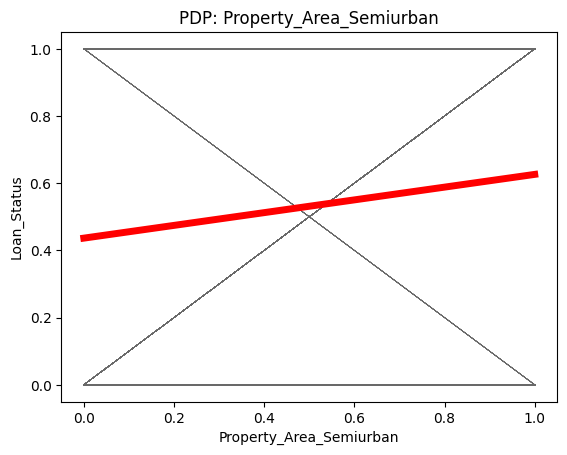

(305, 527)


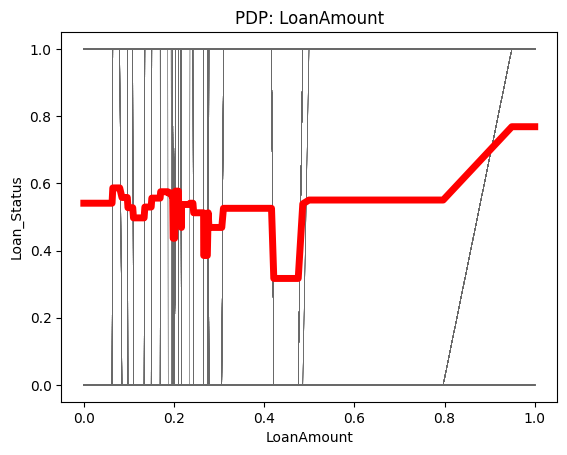

(290, 527)


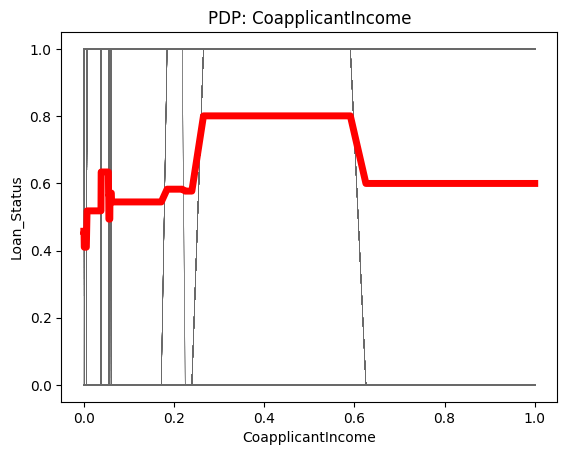

(478, 527)


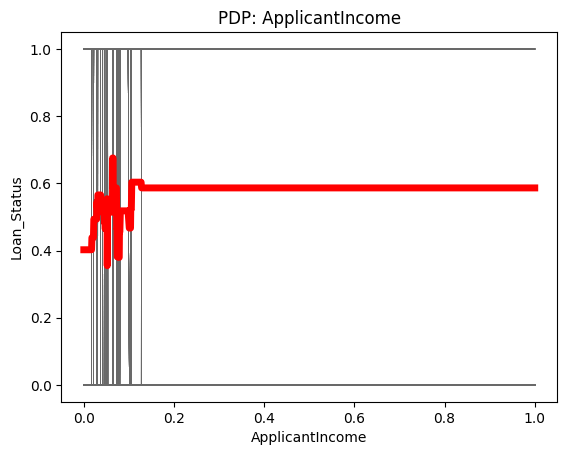

(2, 527)


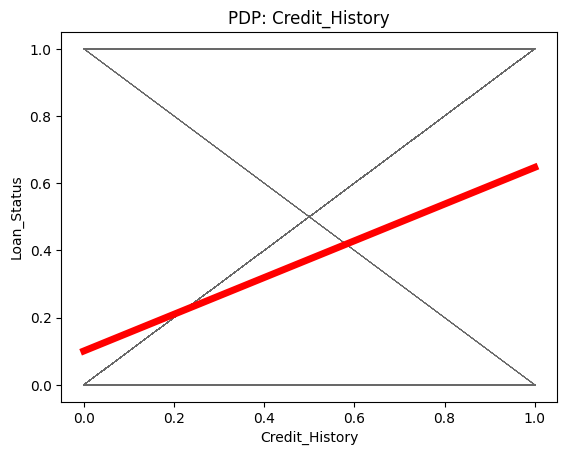

In [19]:
# DTR as an extra
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.20, random_state=seed)
X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(Y_train)
y_test = np.array(Y_test)

categorical_features_indices = [0, 5, 6, 7, 8, 9, 10, 11]
sm = SMOTENC(categorical_features = categorical_features_indices, random_state=42)
X_res, y_res = sm.fit_resample(X_train, Y_train)
X_res = np.array(X_res)
y_res = np.array(y_res)
scaler = MinMaxScaler()
X_res = scaler.fit_transform(X_res)
X_test = scaler.transform(X_test)

DTC = DecisionTreeClassifier(random_state=42)
DTC.fit(X_res, y_res)
train_preds_DTC = DTC.predict(X_res)
test_preds_DTC = DTC.predict(X_test)

clfDTC = DTC
resultDTC = permutation_importance(clfDTC, X_res, y_res, n_repeats=20, random_state=42)
perm_sorted_idxDTC = resultDTC.importances_mean.argsort()
fig, ax1 = plt.subplots(1, 1, figsize=(6, 4))
ax1.boxplot(resultDTC.importances[perm_sorted_idxDTC].T, vert=False, labels=X.columns[perm_sorted_idxDTC])
fig.suptitle('DTC Feature Importance', y=1.05) # don't forget to update title!
fig.tight_layout()
plt.show()

top5_featuresDTC = perm_sorted_idxDTC[7:]
top5_featuresDTC = X.columns[top5_featuresDTC]
print(top5_featuresDTC)

train_X_df = pd.DataFrame(X_res, columns=X.columns)
train_X_df.head()

for col in top5_featuresDTC:
  tmpdf = ice(data=train_X_df, # ice needs a dataframe
            column=col, # the column name
                   predict=DTC.predict) # the predict statement from the
                                          # model
  print(np.shape(tmpdf))
  ice_plot(tmpdf, c='dimgray', linewidth=0.3,
                  plot_pdp=True,
         pdp_kwargs={'linewidth': 5, 'color':'red'})
  plt.title(f'PDP: {col}')
  plt.ylabel('Loan_Status')
  plt.xlabel(col);
  plt.show()

In [20]:
print("DTC")
for feature in top5_featuresDTC:
  print(feature)
print("LR")
for feature in top5_features:
  print(feature)

DTC
Property_Area_Semiurban
LoanAmount
CoapplicantIncome
ApplicantIncome
Credit_History
LR
Education_Not Graduate
Self_Employed_Yes
Property_Area_Urban
Property_Area_Semiurban
Credit_History




*   The two models had different opinions on what the most important features were:

  Credit History was the most important item in both

  Coapplicant income and semiurban property area appeared in both, though in different places

  DTR felt that Loan Amount and Applicant Income were also in the top 5 of importance, while LR felt that Self Employment and Urban Property Area were in the top 5 instead
*   It's easier to visualize the effect of variables in the LR plots, but the DTR plots are more detailed.

